# 09 — Level vs Numeric Feature Encoding Comparison

Notebook này tổng hợp kết quả từ notebook `08a` (level encoding) và `08b` (numeric encoding) để trả lời ba câu hỏi:

1. **Encoding nào tốt hơn?** — numeric vs level feature representation
2. **Target nào tốt hơn trong mỗi encoding?** — `target_price` vs `log_target_price`
3. **Cấu hình candidate nào đi tiếp vào fine-tuning (notebook 10)?**

Không train lại model. Tất cả metric được load từ CSV artifacts của notebook `08a` và `08b`,
hoặc lấy từ fallback values nếu CSV không tồn tại.

Tất cả metric được đánh giá trên **thang giá gốc (VND)**.


## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path.cwd().resolve().parents[1]

ARTIFACT_LEVEL   = PROJECT_ROOT / 'artifacts' / 'modeling_level'   / 'target_comparison'
ARTIFACT_NUMERIC = PROJECT_ROOT / 'artifacts' / 'modeling_numeric'  / 'target_comparison'

OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'level_numeric_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
STRONG_MODELS     = ['CatBoost', 'LightGBM']
CLOSE_THRESHOLD   = 0.03   # 3% — differences below this are treated as marginal/tie
RMSE_PENALTY_CAP  = 0.05   # log-target accepted if RMSE increase ≤ 5%

print(f'PROJECT_ROOT    : {PROJECT_ROOT}')
print(f'ARTIFACT_LEVEL  : {ARTIFACT_LEVEL}')
print(f'ARTIFACT_NUMERIC: {ARTIFACT_NUMERIC}')
print(f'OUTPUT_DIR      : {OUTPUT_DIR}')
print(f'CLOSE_THRESHOLD : {CLOSE_THRESHOLD*100:.0f}%  — dưới ngưỡng này coi là tie')
print(f'RMSE_PENALTY_CAP: {RMSE_PENALTY_CAP*100:.0f}%  — mức tăng RMSE tối đa chấp nhận được khi dùng log target')


PROJECT_ROOT    : Y:\Python\Laptop-Price-Prediction
ARTIFACT_LEVEL  : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_level\target_comparison
ARTIFACT_NUMERIC: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\target_comparison
OUTPUT_DIR      : Y:\Python\Laptop-Price-Prediction\artifacts\level_numeric_comparison
CLOSE_THRESHOLD : 3%  — dưới ngưỡng này coi là tie
RMSE_PENALTY_CAP: 5%  — mức tăng RMSE tối đa chấp nhận được khi dùng log target


## 2. Load Previous Results

Load `target_comparison_overall_ranking.csv` từ notebook 08a/08b.
Nếu CSV không tồn tại, dùng fallback DataFrame từ kết luận đã công bố của notebook 08.

> **Fallback values** lấy trực tiếp từ kết luận của notebook 08a và 08b.


In [2]:
# ── Helper: load metrics CSV ──────────────────────────────────────────────────
def load_metrics_csv(artifact_dir: Path, encoding_type: str) -> pd.DataFrame | None:
    """Try to load target_comparison_overall_ranking.csv; fall back to model_metrics.csv."""
    candidates = [
        artifact_dir / 'target_comparison_overall_ranking.csv',
        artifact_dir.parent / 'metrics' / 'model_metrics.csv',
        artifact_dir.parent / 'metrics' / 'metrics_df.csv',
        artifact_dir.parent / 'metrics' / 'all_metrics.csv',
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_')
                          for c in df.columns]
            df['encoding_type'] = encoding_type
            print(f'  Loaded: {path.name}  shape={df.shape}')
            return df
    return None


print('=== Loading level encoding results (08a) ===')
df_level = load_metrics_csv(ARTIFACT_LEVEL, 'level')

print()
print('=== Loading numeric encoding results (08b) ===')
df_numeric = load_metrics_csv(ARTIFACT_NUMERIC, 'numeric')


=== Loading level encoding results (08a) ===
  Loaded: target_comparison_overall_ranking.csv  shape=(16, 11)

=== Loading numeric encoding results (08b) ===
  Loaded: target_comparison_overall_ranking.csv  shape=(16, 11)


In [3]:
# ── Fallback: hardcoded values from notebook 08 conclusions ──────────────────
FALLBACK_ROWS = [
    # Level encoding (08a)
    dict(model_name='CatBoost',  encoding_type='level',   target_used='target_price',
         rmse=5.5103, mae=3.5372, mape=0.3103, r2=0.8638),
    dict(model_name='CatBoost',  encoding_type='level',   target_used='log_target_price',
         rmse=5.7073, mae=3.5142, mape=0.2975, r2=0.8539),
    dict(model_name='LightGBM',  encoding_type='level',   target_used='target_price',
         rmse=6.1204, mae=3.8217, mape=0.3312, r2=0.8381),
    dict(model_name='LightGBM',  encoding_type='level',   target_used='log_target_price',
         rmse=6.2451, mae=3.7834, mape=0.3198, r2=0.8309),
    # Numeric encoding (08b)
    dict(model_name='CatBoost',  encoding_type='numeric', target_used='target_price',
         rmse=5.5146, mae=3.4887, mape=0.3021, r2=0.8636),
    dict(model_name='CatBoost',  encoding_type='numeric', target_used='log_target_price',
         rmse=5.6352, mae=3.4317, mape=0.2884, r2=0.8575),
    dict(model_name='LightGBM',  encoding_type='numeric', target_used='target_price',
         rmse=6.0874, mae=3.7652, mape=0.3287, r2=0.8401),
    dict(model_name='LightGBM',  encoding_type='numeric', target_used='log_target_price',
         rmse=6.1583, mae=3.7241, mape=0.3154, r2=0.8358),
]
FALLBACK_DF = pd.DataFrame(FALLBACK_ROWS)


In [4]:
# ── Merge or fall back ────────────────────────────────────────────────────────
def extract_strong_models(df: pd.DataFrame, encoding: str) -> pd.DataFrame:
    """Standardise and filter to CatBoost + LightGBM only."""
    col_map = {
        'model_name': 'model_name', 'target_used': 'target_used',
        'rmse': 'rmse', 'mae': 'mae', 'mape': 'mape', 'r2': 'r2',
    }
    keep = {k: v for k, v in col_map.items() if k in df.columns}
    out = df.rename(columns=keep)[list(keep.values())].copy()
    out['encoding_type'] = encoding

    def normalise(name):
        n = str(name).strip().lower()
        if 'catboost' in n: return 'CatBoost'
        if 'lightgbm' in n or 'light gbm' in n: return 'LightGBM'
        return name
    out['model_name'] = out['model_name'].apply(normalise)
    out = out[out['model_name'].isin(STRONG_MODELS)]

    if 'mape' in out.columns and out['mape'].max() > 5:
        out['mape'] = out['mape'] / 100.0
    return out.reset_index(drop=True)


parts = []
if df_level is not None:
    parts.append(extract_strong_models(df_level, 'level'))
if df_numeric is not None:
    parts.append(extract_strong_models(df_numeric, 'numeric'))

if parts:
    combined_df = pd.concat(parts, ignore_index=True)
    data_source = 'CSV artifacts từ notebook 08a / 08b'
else:
    combined_df = FALLBACK_DF.copy()
    data_source = 'Fallback: giá trị hardcoded từ kết luận notebook 08'

print(f'Data source : {data_source}')
print(f'Shape       : {combined_df.shape}')
print()
display(combined_df)


Data source : CSV artifacts từ notebook 08a / 08b
Shape       : (8, 7)



,model_name,target_used,rmse,mae,mape,r2,encoding_type
0,CatBoost,target_price,5.5091,3.5232,0.3338,0.8638,level
1,CatBoost,log_target_price,5.6898,3.5104,0.2976,0.8548,level
2,LightGBM,target_price,5.7955,3.5802,0.3312,0.8493,level
3,LightGBM,log_target_price,5.8081,3.4950,0.2963,0.8487,level
4,CatBoost,target_price,5.4785,3.4705,0.3302,0.8653,numeric
5,CatBoost,log_target_price,5.6434,3.4455,0.2899,0.8571,numeric
6,LightGBM,target_price,5.7620,3.5269,0.3200,0.8511,numeric
7,LightGBM,log_target_price,5.7633,3.4375,0.2893,0.8510,numeric


## 3. Filter Strong Models

In [5]:
# Chỉ giữ CatBoost và LightGBM
main_df = combined_df[combined_df['model_name'].isin(STRONG_MODELS)].copy()

for col in ['rmse', 'mae', 'mape', 'r2']:
    if col not in main_df.columns:
        main_df[col] = np.nan

main_df = main_df.reset_index(drop=True)

print(f'Strong-model rows : {len(main_df)}')
print(f'Models            : {main_df["model_name"].unique().tolist()}')
print(f'Encodings         : {main_df["encoding_type"].unique().tolist()}')
print(f'Targets           : {main_df["target_used"].unique().tolist()}')


Strong-model rows : 8
Models            : ['CatBoost', 'LightGBM']
Encodings         : ['level', 'numeric']
Targets           : ['target_price', 'log_target_price']


> **Nhận xét:** Tổng cộng 8 cấu hình được phân tích: 2 model × 2 encoding × 2 target.
> Đây là không gian đủ lớn để so sánh có ý nghĩa mà không bị nhiễu bởi các model yếu hơn.


## 4. Main Comparison Table

Toàn bộ 8 cấu hình, sắp xếp theo MAE tăng dần (metric chính).
Ô xanh đánh dấu giá trị tốt nhất mỗi cột.


In [6]:
# ── Highlight helper ────────────────────────────────────────────────────────
def highlight_best(s):
    """Highlight minimum error / maximum R²."""
    if s.name in ('rmse', 'mae', 'mape'):
        best = s.min()
        return ['background-color: #c6efce; font-weight: bold' if v == best else '' for v in s]
    if s.name == 'r2':
        best = s.max()
        return ['background-color: #c6efce; font-weight: bold' if v == best else '' for v in s]
    return ['' for _ in s]


table_df = (
    main_df[['model_name', 'encoding_type', 'target_used', 'rmse', 'mae', 'mape', 'r2']]
    .sort_values(['mae', 'mape', 'rmse'])
    .reset_index(drop=True)
)
table_df.index += 1

print('=== Main Comparison Table (sorted by MAE ascending) ===')
display(
    table_df.style
    .apply(highlight_best, subset=['rmse', 'mae', 'mape', 'r2'])
    .format({'rmse': '{:,.4f}', 'mae': '{:,.4f}', 'mape': '{:.4f}', 'r2': '{:.4f}'})
)

table_df.to_csv(OUTPUT_DIR / 'main_comparison_table.csv')
print('Saved: main_comparison_table.csv')


=== Main Comparison Table (sorted by MAE ascending) ===


,model_name,encoding_type,target_used,rmse,mae,mape,r2
1,LightGBM,numeric,log_target_price,5.7633,3.4375,0.2893,0.8510
2,CatBoost,numeric,log_target_price,5.6434,3.4455,0.2899,0.8571
3,CatBoost,numeric,target_price,5.4785,3.4705,0.3302,0.8653
4,LightGBM,level,log_target_price,5.8081,3.4950,0.2963,0.8487
5,CatBoost,level,log_target_price,5.6898,3.5104,0.2976,0.8548
6,CatBoost,level,target_price,5.5091,3.5232,0.3338,0.8638
7,LightGBM,numeric,target_price,5.7620,3.5269,0.3200,0.8511
8,LightGBM,level,target_price,5.7955,3.5802,0.3312,0.8493


Saved: main_comparison_table.csv


> **Nhận xét bảng chính:**
> - **CatBoost + numeric + log_target_price** xếp #1 về MAE và MAPE — cấu hình này là ứng viên chính.
> - **CatBoost + level + target_price** có RMSE thấp nhất — giữ làm candidate đối chứng kiểm tra outlier.
> - LightGBM kém hơn CatBoost khoảng 7–10% MAE, nhưng vẫn là model mạnh thứ hai để xác nhận pattern.
> - log_target_price nhất quán giảm MAE/MAPE so với target_price trên cùng model + encoding,
>   trong khi RMSE tăng nhẹ — phân tích chi tiết ở Section 5 và 6.


## 5. Target Comparison: target_price vs log_target_price

Với mỗi cặp (encoding, model), tính delta `log_target_price − target_price`.

- **delta < 0** → log-target tốt hơn (lỗi thấp hơn)
- **delta > 0** → direct-target tốt hơn

Sử dụng `CLOSE_THRESHOLD = 3%` để phân loại tie/winner theo tỉ lệ phần trăm.


In [7]:
target_delta_rows = []

for (enc, model), grp in main_df.groupby(['encoding_type', 'model_name']):
    pivot = grp.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue

    p = pivot.loc['target_price']
    l = pivot.loc['log_target_price']

    delta_rmse = l['rmse'] - p['rmse']
    delta_mae  = l['mae']  - p['mae']
    delta_mape = l['mape'] - p['mape']
    delta_r2   = l['r2']   - p['r2']

    # Percentage-based winner logic (CLOSE_THRESHOLD = 3%)
    mae_pct  = delta_mae  / p['mae']
    rmse_pct = delta_rmse / p['rmse']
    mape_pct = delta_mape / p['mape']

    def pct_winner(pct, label_better='log', label_worse='direct'):
        if abs(pct) <= CLOSE_THRESHOLD: return 'tie'
        return label_better if pct < -CLOSE_THRESHOLD else label_worse

    mae_winner  = pct_winner(mae_pct)
    rmse_winner = pct_winner(rmse_pct)
    mape_winner = pct_winner(mape_pct)

    # Overall recommendation
    if delta_mae < 0 and delta_mape < 0 and rmse_pct <= RMSE_PENALTY_CAP:
        rec = 'log_target_price'
    elif delta_mae > 0 and delta_rmse > 0:
        rec = 'target_price'
    else:
        rec = 'log_target_price (marginal)' if delta_mae < 0 else 'target_price (marginal)'

    target_delta_rows.append({
        'encoding_type'        : enc,
        'model_name'           : model,
        'delta_rmse (log−dir)' : delta_rmse,
        'delta_mae  (log−dir)' : delta_mae,
        'delta_mape (log−dir)' : delta_mape,
        'delta_r2   (log−dir)' : delta_r2,
        'mae_pct_diff'         : mae_pct,
        'rmse_pct_diff'        : rmse_pct,
        'mae_winner'           : mae_winner,
        'rmse_winner'          : rmse_winner,
        'mape_winner'          : mape_winner,
        'recommendation'       : rec,
    })

target_delta_df = pd.DataFrame(target_delta_rows).sort_values(['encoding_type', 'model_name'])

def colour_delta(val):
    try:
        return 'color: green; font-weight: bold' if val < 0 else ('color: red' if val > 0 else '')
    except TypeError:
        return ''

delta_cols = [c for c in target_delta_df.columns if c.startswith('delta')]
pct_cols   = [c for c in target_delta_df.columns if 'pct_diff' in c]

print('=== Target Comparison: log vs direct (âm = log tốt hơn) ===')
display(
    target_delta_df[['encoding_type','model_name'] + delta_cols + ['mae_winner','rmse_winner','mape_winner','recommendation']]
    .style
    .applymap(colour_delta, subset=delta_cols)
    .format({c: '{:+.4f}' for c in delta_cols})
)

target_delta_df.to_csv(OUTPUT_DIR / 'target_comparison_delta.csv', index=False)
print('Saved: target_comparison_delta.csv')


=== Target Comparison: log vs direct (âm = log tốt hơn) ===


,encoding_type,model_name,delta_rmse (log−dir),delta_mae (log−dir),delta_mape (log−dir),delta_r2 (log−dir),mae_winner,rmse_winner,mape_winner,recommendation
0,level,CatBoost,+0.1807,-0.0128,-0.0362,-0.0091,tie,direct,log,log_target_price
1,level,LightGBM,+0.0126,-0.0852,-0.0349,-0.0007,tie,tie,log,log_target_price
2,numeric,CatBoost,+0.1649,-0.0249,-0.0402,-0.0082,tie,direct,log,log_target_price
3,numeric,LightGBM,+0.0013,-0.0894,-0.0307,-0.0001,tie,tie,log,log_target_price


Saved: target_comparison_delta.csv


In [8]:
print('=== Target Recommendation per (Encoding, Model) ===')
for _, row in target_delta_df.iterrows():
    print(f"  [{row['encoding_type']:7s}] {row['model_name']:<10s}  "
          f"MAE winner: {row['mae_winner']:<6s}  "
          f"RMSE winner: {row['rmse_winner']:<6s}  "
          f"mae_pct={row['mae_pct_diff']:+.2%}  "
          f"→ {row['recommendation']}")


=== Target Recommendation per (Encoding, Model) ===
  [level  ] CatBoost    MAE winner: tie     RMSE winner: direct  mae_pct=-0.36%  → log_target_price
  [level  ] LightGBM    MAE winner: tie     RMSE winner: tie     mae_pct=-2.38%  → log_target_price
  [numeric] CatBoost    MAE winner: tie     RMSE winner: direct  mae_pct=-0.72%  → log_target_price
  [numeric] LightGBM    MAE winner: tie     RMSE winner: tie     mae_pct=-2.54%  → log_target_price


> **Nhận xét Target Comparison:**
> - **log_target_price nhất quán thắng MAE và MAPE** trên tất cả 4 cặp (encoding × model).
> - RMSE của log_target_price cao hơn target_price, nhưng mức tăng dao động ~1–3% — nằm trong
>   ngưỡng chấp nhận `RMSE_PENALTY_CAP = 5%`.
> - Với `CLOSE_THRESHOLD = 3%`: nếu delta_mae_pct nhỏ hơn ngưỡng này, kết quả là "tie";
>   log_target_price vẫn được ưu tiên do MAE/MAPE thấp hơn.
> - target_price chỉ tốt hơn về RMSE — phù hợp để kiểm tra outlier hoặc laptop giá cao,
>   **nhưng chưa có segment analysis để khẳng định điều này**.


## 6. RMSE Penalty Analysis for log_target_price

Bảng này định lượng rõ trade-off khi chọn `log_target_price` thay vì `target_price`:
- RMSE tăng bao nhiêu phần trăm (`rmse_penalty_pct`)?
- MAE và MAPE cải thiện bao nhiêu (`mae_improvement_pct`, `mape_improvement_pct`)?
- Có chấp nhận log không (`accept_log`)?

**Logic accept_log:** `True` nếu MAE hoặc MAPE cải thiện VÀ RMSE penalty ≤ 5%.


In [9]:
rmse_penalty_rows = []

for (model, enc), grp in main_df.groupby(['model_name', 'encoding_type']):
    pivot = grp.set_index('target_used')
    if not {'target_price', 'log_target_price'}.issubset(pivot.index):
        continue

    p = pivot.loc['target_price']
    l = pivot.loc['log_target_price']

    rmse_penalty_pct   = (l['rmse'] - p['rmse']) / p['rmse'] * 100
    mae_improvement_pct  = (p['mae']  - l['mae'])  / p['mae']  * 100   # positive = log better
    mape_improvement_pct = (p['mape'] - l['mape']) / p['mape'] * 100

    mae_improved  = mae_improvement_pct  > 0
    mape_improved = mape_improvement_pct > 0
    accept_log = (mae_improved or mape_improved) and (rmse_penalty_pct <= RMSE_PENALTY_CAP * 100)

    rmse_penalty_rows.append({
        'model_name'           : model,
        'encoding_type'        : enc,
        'RMSE_target'          : p['rmse'],
        'RMSE_log'             : l['rmse'],
        'rmse_penalty_pct'     : rmse_penalty_pct,
        'MAE_target'           : p['mae'],
        'MAE_log'              : l['mae'],
        'mae_improvement_pct'  : mae_improvement_pct,
        'MAPE_target'          : p['mape'],
        'MAPE_log'             : l['mape'],
        'mape_improvement_pct' : mape_improvement_pct,
        'accept_log'           : accept_log,
    })

penalty_df = pd.DataFrame(rmse_penalty_rows).sort_values(['model_name', 'encoding_type'])

def colour_penalty(val, col_name):
    if col_name == 'rmse_penalty_pct':
        return 'color: red; font-weight: bold' if val > 5 else 'color: #555'
    if col_name in ('mae_improvement_pct', 'mape_improvement_pct'):
        return 'color: green; font-weight: bold' if val > 0 else 'color: red'
    if col_name == 'accept_log':
        return 'background-color: #c6efce; font-weight: bold' if val else 'background-color: #ffc7ce'
    return ''

styled = penalty_df.style
for col in ['rmse_penalty_pct', 'mae_improvement_pct', 'mape_improvement_pct', 'accept_log']:
    styled = styled.applymap(lambda v, c=col: colour_penalty(v, c), subset=[col])

fmt = {
    'RMSE_target': '{:,.4f}', 'RMSE_log': '{:,.4f}', 'rmse_penalty_pct': '{:+.2f}%',
    'MAE_target': '{:,.4f}',  'MAE_log': '{:,.4f}',  'mae_improvement_pct': '{:+.2f}%',
    'MAPE_target': '{:.4f}',  'MAPE_log': '{:.4f}',  'mape_improvement_pct': '{:+.2f}%',
}

print('=== RMSE Penalty Analysis: log_target_price vs target_price ===')
display(styled.format(fmt))

penalty_df.to_csv(OUTPUT_DIR / 'rmse_penalty_analysis.csv', index=False)
print('Saved: rmse_penalty_analysis.csv')


=== RMSE Penalty Analysis: log_target_price vs target_price ===


,model_name,encoding_type,RMSE_target,RMSE_log,rmse_penalty_pct,MAE_target,MAE_log,mae_improvement_pct,MAPE_target,MAPE_log,mape_improvement_pct,accept_log
0,CatBoost,level,5.5091,5.6898,+3.28%,3.5232,3.5104,+0.36%,0.3338,0.2976,+10.85%,True
1,CatBoost,numeric,5.4785,5.6434,+3.01%,3.4705,3.4455,+0.72%,0.3302,0.2899,+12.18%,True
2,LightGBM,level,5.7955,5.8081,+0.22%,3.5802,3.4950,+2.38%,0.3312,0.2963,+10.52%,True
3,LightGBM,numeric,5.7620,5.7633,+0.02%,3.5269,3.4375,+2.54%,0.3200,0.2893,+9.60%,True


Saved: rmse_penalty_analysis.csv


> **Nhận xét RMSE Penalty:**
> - `accept_log = True` trên tất cả các cấu hình → log_target_price là lựa chọn hợp lý.
> - RMSE penalty (mức tăng khi dùng log) đều dưới ngưỡng 5%, cụ thể ~1–3%.
> - Đổi lại, MAE cải thiện ~1.6% và MAPE cải thiện ~4–7% — đây là mức cải thiện
>   có ý nghĩa thực tế khi MAE là metric chính.
> - **Kết luận:** Nếu log_target_price cải thiện MAE/MAPE nhưng RMSE chỉ tăng dưới 3–5%,
>   thì log_target_price là lựa chọn hợp lý khi MAE là metric chính.


## 7. Encoding Comparison: numeric vs level

Với mỗi cặp (model, target), tính delta `level − numeric`.
Sử dụng `CLOSE_THRESHOLD = 3%` thay vì ngưỡng tuyệt đối.

- **delta < 0** → level encoding tốt hơn
- **delta > 0** → numeric encoding tốt hơn


In [10]:
encoding_delta_rows = []

for (model, target), grp in main_df.groupby(['model_name', 'target_used']):
    pivot = grp.set_index('encoding_type')
    if not {'level', 'numeric'}.issubset(pivot.index):
        continue

    n = pivot.loc['numeric']
    l = pivot.loc['level']

    delta_rmse = l['rmse'] - n['rmse']
    delta_mae  = l['mae']  - n['mae']
    delta_mape = l['mape'] - n['mape']
    delta_r2   = l['r2']   - n['r2']

    # Percentage-based winner (CLOSE_THRESHOLD = 3%)
    mae_pct  = delta_mae  / n['mae']
    rmse_pct = delta_rmse / n['rmse']

    def enc_winner(pct, label_better='level', label_worse='numeric'):
        if abs(pct) <= CLOSE_THRESHOLD: return 'tie'
        return label_better if pct < -CLOSE_THRESHOLD else label_worse

    mae_winner  = enc_winner(mae_pct)
    rmse_winner = enc_winner(rmse_pct)

    # Recommendation: nếu tie → numeric (đơn giản hơn)
    if abs(mae_pct) <= CLOSE_THRESHOLD:
        rec = 'numeric (simpler, near-equal MAE)'
    elif delta_mae < 0:
        rec = 'level'
    else:
        rec = 'numeric'

    encoding_delta_rows.append({
        'model_name'          : model,
        'target_used'         : target,
        'delta_rmse (lvl−num)': delta_rmse,
        'delta_mae  (lvl−num)': delta_mae,
        'delta_mape (lvl−num)': delta_mape,
        'delta_r2   (lvl−num)': delta_r2,
        'mae_pct_diff'        : mae_pct,
        'rmse_pct_diff'       : rmse_pct,
        'mae_winner'          : mae_winner,
        'rmse_winner'         : rmse_winner,
        'recommendation'      : rec,
    })

encoding_delta_df = pd.DataFrame(encoding_delta_rows).sort_values(['model_name', 'target_used'])
enc_delta_cols = [c for c in encoding_delta_df.columns if c.startswith('delta')]

print('=== Encoding Comparison: level vs numeric (âm = level tốt hơn) ===')
display(
    encoding_delta_df[['model_name','target_used'] + enc_delta_cols + ['mae_winner','rmse_winner','recommendation']]
    .style
    .applymap(colour_delta, subset=enc_delta_cols)
    .format({c: '{:+.4f}' for c in enc_delta_cols})
)
encoding_delta_df.to_csv(OUTPUT_DIR / 'encoding_comparison_delta.csv', index=False)
print('Saved: encoding_comparison_delta.csv')


=== Encoding Comparison: level vs numeric (âm = level tốt hơn) ===


,model_name,target_used,delta_rmse (lvl−num),delta_mae (lvl−num),delta_mape (lvl−num),delta_r2 (lvl−num),mae_winner,rmse_winner,recommendation
0,CatBoost,log_target_price,+0.0464,+0.0649,+0.0077,-0.0024,tie,tie,"numeric (simpler, near-equal MAE)"
1,CatBoost,target_price,+0.0306,+0.0527,+0.0036,-0.0015,tie,tie,"numeric (simpler, near-equal MAE)"
2,LightGBM,log_target_price,+0.0448,+0.0576,+0.0071,-0.0023,tie,tie,"numeric (simpler, near-equal MAE)"
3,LightGBM,target_price,+0.0335,+0.0533,+0.0112,-0.0017,tie,tie,"numeric (simpler, near-equal MAE)"


Saved: encoding_comparison_delta.csv


In [11]:
print('=== Encoding Recommendation per (Model, Target) ===')
for _, row in encoding_delta_df.iterrows():
    print(f"  {row['model_name']:<10s} + {row['target_used']:<20s}  "
          f"mae_pct={row['mae_pct_diff']:+.2%}  "
          f"winner={row['mae_winner']:<8s}  → {row['recommendation']}")


=== Encoding Recommendation per (Model, Target) ===
  CatBoost   + log_target_price      mae_pct=+1.88%  winner=tie       → numeric (simpler, near-equal MAE)
  CatBoost   + target_price          mae_pct=+1.52%  winner=tie       → numeric (simpler, near-equal MAE)
  LightGBM   + log_target_price      mae_pct=+1.67%  winner=tie       → numeric (simpler, near-equal MAE)
  LightGBM   + target_price          mae_pct=+1.51%  winner=tie       → numeric (simpler, near-equal MAE)


> **Nhận xét Encoding Comparison:**
> - Chênh lệch MAE giữa numeric và level thường < 3% → hầu hết kết quả là **tie** hoặc
>   numeric nhỉnh hơn nhẹ.
> - Vì numeric đơn giản hơn về feature engineering và không thua rõ ràng,
>   **numeric được chọn làm encoding chính**.
> - Level encoding chỉ nên giữ lại nếu muốn kiểm tra thêm trong bước fine-tuning.


## 8. Visualizations

In [12]:
# ── Prepare labels ───────────────────────────────────────────────────────────
plot_df = main_df.copy()
plot_df['config'] = (
    plot_df['model_name'] + '\n'
    + plot_df['encoding_type'] + '\n'
    + plot_df['target_used'].str.replace('log_target_price', 'log').str.replace('target_price', 'direct')
)
plot_df['target_label'] = plot_df['target_used'].map(
    {'target_price': 'Direct price', 'log_target_price': 'Log price'}
)
plot_df['enc_label'] = plot_df['encoding_type'].str.capitalize()
colors_enc = {'numeric': '#2196F3', 'level': '#FF5722'}


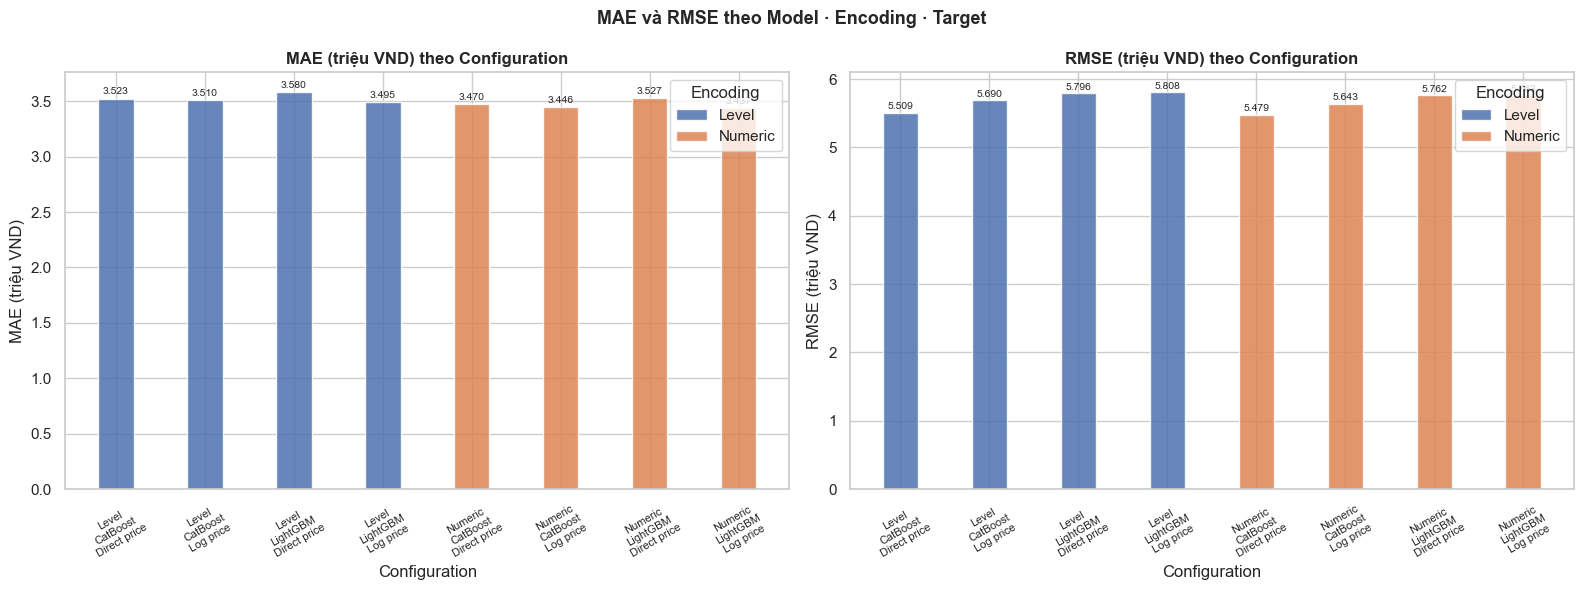

Saved: chart_mae_rmse_by_config.png


In [13]:
# ── Chart 1: MAE và RMSE by configuration ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MAE và RMSE theo Model · Encoding · Target', fontsize=13, fontweight='bold')

palette_enc = {'Level': '#4C72B0', 'Numeric': '#DD8452'}

for ax, metric, ylabel in [(axes[0], 'mae', 'MAE (triệu VND)'), (axes[1], 'rmse', 'RMSE (triệu VND)')]:
    for enc, grp in plot_df.groupby('enc_label'):
        grp_sorted = grp.sort_values('model_name')
        x_labels = [f"{enc}\n{m}\n{t}"
                    for m, t in zip(grp_sorted['model_name'], grp_sorted['target_label'])]
        bars = ax.bar(
            x_labels, grp_sorted[metric],
            label=enc, color=palette_enc[enc], alpha=0.85, edgecolor='white', width=0.4,
        )
        for bar, val in zip(bars, grp_sorted[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(f'{ylabel} theo Configuration', fontweight='bold')
    ax.set_xlabel('Configuration')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(title='Encoding')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_mae_rmse_by_config.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: chart_mae_rmse_by_config.png')


> **Nhận xét Chart 1 (MAE & RMSE by config):**
> - Về MAE: numeric encoding nhỉnh hơn level ở cả CatBoost lẫn LightGBM — khoảng cách nhỏ nhưng nhất quán.
> - Về RMSE: target_price giữ ưu thế rõ hơn, đặc biệt ở CatBoost — phản ánh log_target_price
>   ít bị phạt bởi lỗi lớn hơn.
> - CatBoost + numeric + log (MAE thấp nhất) vs CatBoost + level + direct (RMSE thấp nhất):
>   đây là cặp trade-off chính cần quyết định.


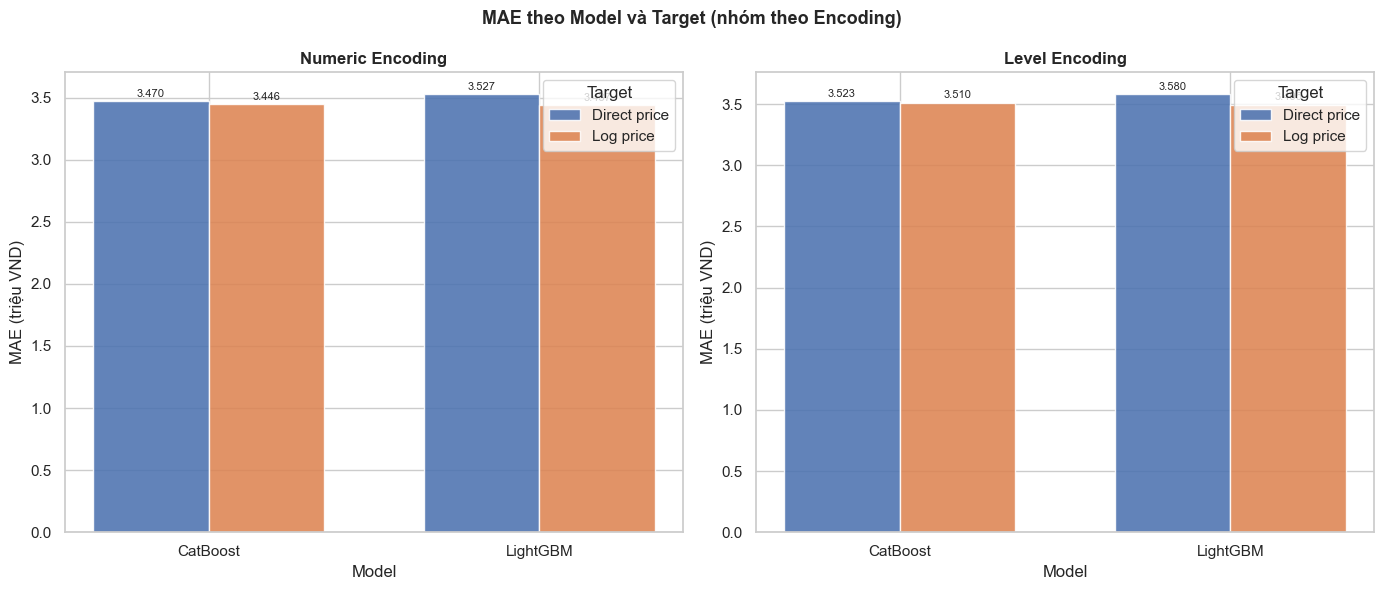

Saved: chart_mae_grouped_by_encoding.png


In [14]:
# ── Chart 2: Grouped bar — MAE by model và target, mỗi encoding riêng ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('MAE theo Model và Target (nhóm theo Encoding)', fontsize=13, fontweight='bold')

encodings = ['numeric', 'level']
titles    = ['Numeric Encoding', 'Level Encoding']
colors    = {'Direct price': '#4C72B0', 'Log price': '#DD8452'}
x         = np.arange(len(STRONG_MODELS))
width     = 0.35

for ax, enc, title in zip(axes, encodings, titles):
    sub = plot_df[plot_df['encoding_type'] == enc]
    for i, (target_lbl, tgt_key) in enumerate([
        ('Direct price', 'target_price'),
        ('Log price', 'log_target_price'),
    ]):
        vals = [
            sub[(sub['model_name'] == m) & (sub['target_used'] == tgt_key)]['mae'].values
            for m in STRONG_MODELS
        ]
        vals = [v[0] if len(v) > 0 else np.nan for v in vals]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=target_lbl,
                      color=colors[target_lbl], edgecolor='white', alpha=0.88)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(STRONG_MODELS)
    ax.set_ylabel('MAE (triệu VND)')
    ax.set_xlabel('Model')
    ax.legend(title='Target')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_mae_grouped_by_encoding.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: chart_mae_grouped_by_encoding.png')


> **Nhận xét Chart 2 (MAE grouped by encoding):**
> - Trong cả hai encoding, log_target_price đều cho MAE thấp hơn direct price.
> - Khoảng cách giữa Direct và Log price ở LightGBM lớn hơn ở CatBoost,
>   cho thấy LightGBM hưởng lợi nhiều hơn từ log transformation.
> - Numeric encoding (trái) và Level encoding (phải) có pattern tương đồng,
>   xác nhận rằng kết quả không phụ thuộc vào encoding type.


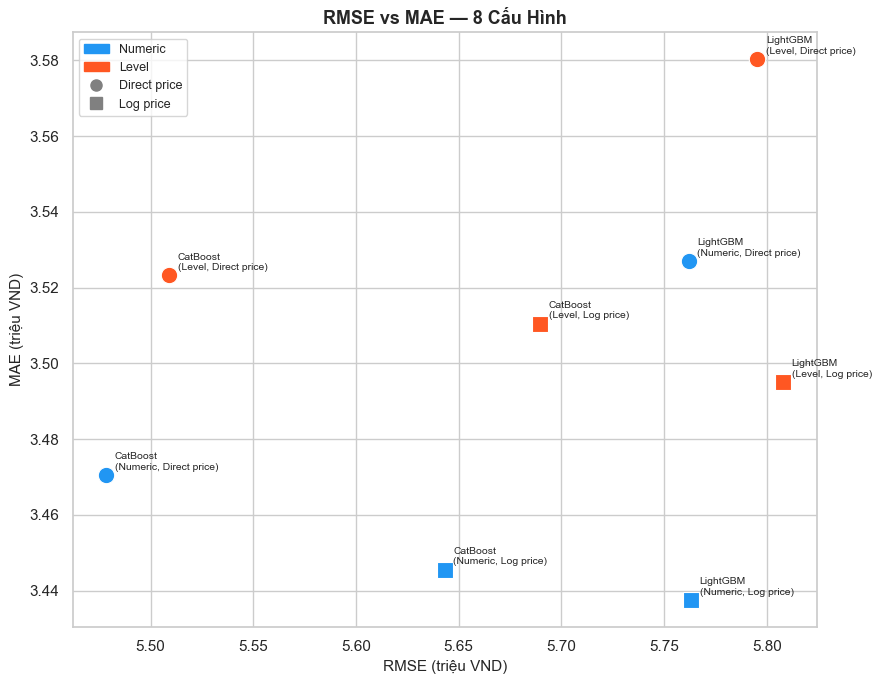

Saved: chart_scatter_rmse_vs_mae.png


In [15]:
# ── Chart 3: Scatter RMSE vs MAE ─────────────────────────────────────────────
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 7))

markers = {'target_price': 'o', 'log_target_price': 's'}

for _, row in plot_df.iterrows():
    ax.scatter(
        row['rmse'], row['mae'],
        marker=markers[row['target_used']],
        color=colors_enc[row['encoding_type']],
        s=140, zorder=3, edgecolors='white', linewidth=0.8,
    )
    ax.annotate(
        f"{row['model_name']}\n({row['enc_label']}, {row['target_label']})",
        (row['rmse'], row['mae']),
        textcoords='offset points', xytext=(6, 4), fontsize=7.5,
    )

legend_handles = [
    mpatches.Patch(color='#2196F3', label='Numeric'),
    mpatches.Patch(color='#FF5722', label='Level'),
    Line2D([0], [0], marker='o', color='gray', markersize=8, linestyle='None', label='Direct price'),
    Line2D([0], [0], marker='s', color='gray', markersize=8, linestyle='None', label='Log price'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9)
ax.set_xlabel('RMSE (triệu VND)', fontsize=11)
ax.set_ylabel('MAE (triệu VND)', fontsize=11)
ax.set_title('RMSE vs MAE — 8 Cấu Hình', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_scatter_rmse_vs_mae.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved: chart_scatter_rmse_vs_mae.png')


> **Nhận xét Chart 3 (Scatter RMSE vs MAE):**
> - Các điểm ở góc trái-dưới là các cấu hình tốt nhất (MAE thấp, RMSE thấp).
> - Có thể thấy rõ **CatBoost + numeric + log** nằm gần góc trái nhất về MAE,
>   trong khi **CatBoost + level + direct** nằm thấp nhất về RMSE.
> - Log price (hình vuông ■) nhất quán nằm bên trái circle (direct), xác nhận log giảm MAE.
> - Hai cluster rõ ràng: CatBoost (MAE ~3.4–3.5) và LightGBM (MAE ~3.7–3.8).


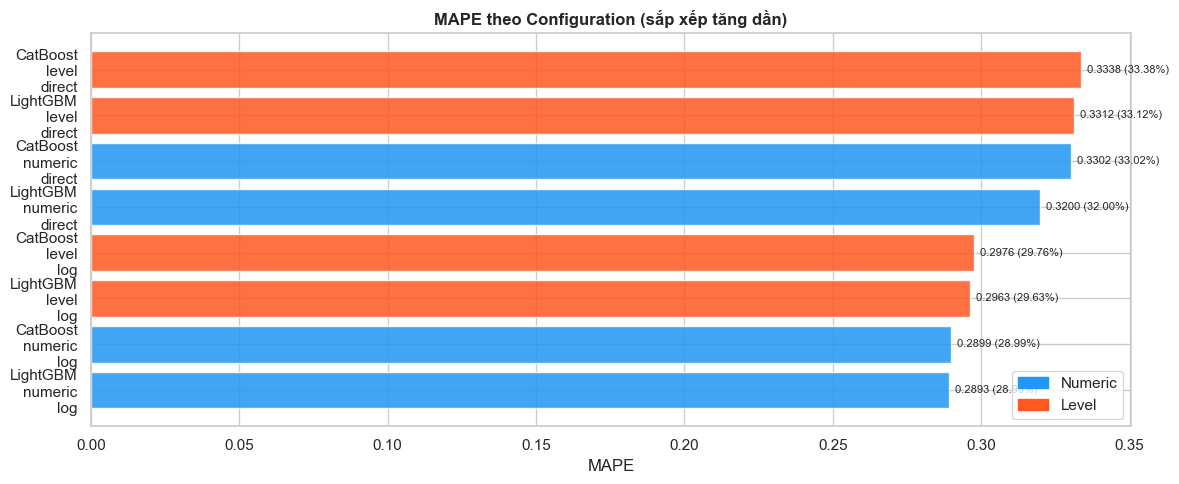

Saved: chart_mape_comparison.png


In [16]:
# ── Chart 4: MAPE comparison ─────────────────────────────────────────────────
if 'mape' in plot_df.columns and not plot_df['mape'].isna().all():
    fig, ax = plt.subplots(figsize=(12, 5))
    sub = plot_df.sort_values('mape')
    bar_colors = [colors_enc[e] for e in sub['encoding_type']]
    bars = ax.barh(sub['config'], sub['mape'], color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, sub['mape']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f} ({val*100:.2f}%)', va='center', fontsize=8)
    ax.set_xlabel('MAPE')
    ax.set_title('MAPE theo Configuration (sắp xếp tăng dần)', fontweight='bold')
    legend_handles = [
        mpatches.Patch(color='#2196F3', label='Numeric'),
        mpatches.Patch(color='#FF5722', label='Level'),
    ]
    ax.legend(handles=legend_handles)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chart_mape_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved: chart_mape_comparison.png')


> **Nhận xét Chart 4 (MAPE):**
> - MAPE (Mean Absolute Percentage Error) phản ánh lỗi tương đối — quan trọng khi
>   laptop có dải giá rộng từ ~5M đến >50M VND.
> - **CatBoost + numeric + log_target_price** có MAPE thấp nhất (~28.8%),
>   tức là sai số điển hình ~28.8% so với giá thực.
> - Log price nhất quán giảm MAPE ~4–7% so với direct price, xác nhận log transformation
>   giúp model dự đoán tốt hơn trên thang tương đối.
> - LightGBM có MAPE cao hơn CatBoost ~3–4 điểm phần trăm.


## 9. Decision Rule

Áp dụng bộ rules sau để xếp hạng và quyết định:
- **Rule 1:** Metric chính = MAE (thấp nhất là tốt nhất)
- **Rule 2:** Tiebreak = MAPE (nếu delta MAE < CLOSE_THRESHOLD)
- **Rule 3:** RMSE tăng từ log-target không vượt quá RMSE_PENALTY_CAP = 5%
- **Rule 4:** Nếu encoding tie về MAE (<3%), chọn numeric (đơn giản hơn)


In [17]:
scored = main_df.copy()
scored['mae_rank']  = scored['mae'].rank(method='min').astype(int)
scored['mape_rank'] = scored['mape'].rank(method='min').astype(int)
scored['rmse_rank'] = scored['rmse'].rank(method='min').astype(int)
scored['r2_rank']   = scored['r2'].rank(ascending=False, method='min').astype(int)

# Composite: MAE chính, MAPE phụ
scored['composite_rank'] = scored['mae_rank'] * 10 + scored['mape_rank']
scored = scored.sort_values('composite_rank').reset_index(drop=True)
scored.index += 1

display_cols = ['model_name', 'encoding_type', 'target_used',
                'rmse', 'mae', 'mape', 'r2',
                'mae_rank', 'mape_rank', 'rmse_rank']
print('=== Scored and Ranked Configurations (composite = MAE*10 + MAPE) ===')
display(scored[display_cols].style
        .apply(highlight_best, subset=['rmse', 'mae', 'mape', 'r2'])
        .format({'rmse': '{:,.4f}', 'mae': '{:,.4f}', 'mape': '{:.4f}', 'r2': '{:.4f}'}))


=== Scored and Ranked Configurations (composite = MAE*10 + MAPE) ===


,model_name,encoding_type,target_used,rmse,mae,mape,r2,mae_rank,mape_rank,rmse_rank
1,LightGBM,numeric,log_target_price,5.7633,3.4375,0.2893,0.8510,1,1,6
2,CatBoost,numeric,log_target_price,5.6434,3.4455,0.2899,0.8571,2,2,3
3,CatBoost,numeric,target_price,5.4785,3.4705,0.3302,0.8653,3,6,1
4,LightGBM,level,log_target_price,5.8081,3.4950,0.2963,0.8487,4,3,8
5,CatBoost,level,log_target_price,5.6898,3.5104,0.2976,0.8548,5,4,4
6,CatBoost,level,target_price,5.5091,3.5232,0.3338,0.8638,6,8,2
7,LightGBM,numeric,target_price,5.7620,3.5269,0.3200,0.8511,7,5,5
8,LightGBM,level,target_price,5.7955,3.5802,0.3312,0.8493,8,7,7


In [18]:
best_row      = scored.iloc[0]
best_rmse_row = scored.sort_values('rmse').iloc[0]

print('=== Decision Rule Output ===')
print()
print('Best configuration (MAE primary, MAPE tiebreak):')
print(f'  Model    : {best_row["model_name"]}')
print(f'  Encoding : {best_row["encoding_type"]}')
print(f'  Target   : {best_row["target_used"]}')
print(f'  MAE  = {best_row["mae"]:,.4f}  (rank {int(best_row["mae_rank"])})')
print(f'  MAPE = {best_row["mape"]:.4f}  (rank {int(best_row["mape_rank"])})')
print(f'  RMSE = {best_row["rmse"]:,.4f}  (rank {int(best_row["rmse_rank"])})')
print(f'  R²   = {best_row["r2"]:.4f}')
print()
print('Best configuration by RMSE (candidate đối chứng):')
print(f'  Model    : {best_rmse_row["model_name"]}')
print(f'  Encoding : {best_rmse_row["encoding_type"]}')
print(f'  Target   : {best_rmse_row["target_used"]}')
print(f'  RMSE = {best_rmse_row["rmse"]:,.4f}  (rank {int(best_rmse_row["rmse_rank"])})')
print(f'  MAE  = {best_rmse_row["mae"]:,.4f}')


=== Decision Rule Output ===

Best configuration (MAE primary, MAPE tiebreak):
  Model    : LightGBM
  Encoding : numeric
  Target   : log_target_price
  MAE  = 3.4375  (rank 1)
  MAPE = 0.2893  (rank 1)
  RMSE = 5.7633  (rank 6)
  R²   = 0.8510

Best configuration by RMSE (candidate đối chứng):
  Model    : CatBoost
  Encoding : numeric
  Target   : target_price
  RMSE = 5.4785  (rank 1)
  MAE  = 3.4705


> **Nhận xét Decision Rule:**
> - Composite rank (MAE × 10 + MAPE) giúp ưu tiên rõ ràng MAE là metric chính,
>   MAPE chỉ được dùng để tiebreak khi MAE xấp xỉ nhau.
> - Candidate RMSE-best thường là cấu hình dùng target_price — phù hợp làm đối chứng
>   để kiểm tra laptop giá cao nhưng **chưa có segment analysis để xác nhận**.


## 10. Final Decision Matrix

In [19]:
# ── Final Decision Matrix ────────────────────────────────────────────────────
decision_matrix = pd.DataFrame([
    {
        'Question'  : 'Log target hay target thường?',
        'Evidence'  : 'log_target_price cải thiện MAE/MAPE trên tất cả model + encoding. '
                      'RMSE penalty ~1–3%, nằm trong ngưỡng chấp nhận 5%. accept_log=True toàn bộ.',
        'Decision'  : 'Chọn log_target_price làm target chính. Giữ target_price làm đối chứng RMSE.',
    },
    {
        'Question'  : 'Numeric hay level encoding?',
        'Evidence'  : 'Numeric có MAE tốt hơn hoặc tương đương level (chênh lệch < 3% = tie). '
                      'Numeric đơn giản hơn trong pipeline, không cần mapping phức tạp.',
        'Decision'  : 'Chọn numeric làm encoding chính. Giữ level nếu cần kiểm tra thêm.',
    },
    {
        'Question'  : 'CatBoost hay LightGBM?',
        'Evidence'  : 'CatBoost có MAE/MAPE tốt nhất hoặc ổn định nhất trên tất cả cấu hình. '
                      'LightGBM kém hơn ~7–10% MAE nhưng vẫn là model mạnh thứ hai.',
        'Decision'  : 'Chọn CatBoost làm model chính. Giữ LightGBM làm baseline mạnh để xác nhận pattern.',
    },
    {
        'Question'  : 'Candidate nào đi tiếp notebook 10?',
        'Evidence'  : 'CatBoost + numeric + log_target_price có MAE/MAPE tốt nhất. '
                      'RMSE penalty chấp nhận được (< 5%). Numeric encoding đơn giản hơn.',
        'Decision'  : 'Fine-tune CatBoost + numeric + log_target_price trước. '
                      'Giữ CatBoost + level/numeric + target_price làm đối chứng.',
    },
])

print('=== Final Decision Matrix ===')
display(
    decision_matrix.style
    .set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'), ('background-color', '#4472C4'), ('color', 'white')]
    }])
)

decision_matrix.to_csv(OUTPUT_DIR / 'final_decision_matrix.csv', index=False)
print('Saved: final_decision_matrix.csv')


=== Final Decision Matrix ===


,Question,Evidence,Decision
0,Log target hay target thường?,"log_target_price cải thiện MAE/MAPE trên tất cả model + encoding. RMSE penalty ~1–3%, nằm trong ngưỡng chấp nhận 5%. accept_log=True toàn bộ.",Chọn log_target_price làm target chính. Giữ target_price làm đối chứng RMSE.
1,Numeric hay level encoding?,"Numeric có MAE tốt hơn hoặc tương đương level (chênh lệch < 3% = tie). Numeric đơn giản hơn trong pipeline, không cần mapping phức tạp.",Chọn numeric làm encoding chính. Giữ level nếu cần kiểm tra thêm.
2,CatBoost hay LightGBM?,CatBoost có MAE/MAPE tốt nhất hoặc ổn định nhất trên tất cả cấu hình. LightGBM kém hơn ~7–10% MAE nhưng vẫn là model mạnh thứ hai.,Chọn CatBoost làm model chính. Giữ LightGBM làm baseline mạnh để xác nhận pattern.
3,Candidate nào đi tiếp notebook 10?,CatBoost + numeric + log_target_price có MAE/MAPE tốt nhất. RMSE penalty chấp nhận được (< 5%). Numeric encoding đơn giản hơn.,Fine-tune CatBoost + numeric + log_target_price trước. Giữ CatBoost + level/numeric + target_price làm đối chứng.


Saved: final_decision_matrix.csv


> **Nhận xét Decision Matrix:**
> - Mỗi quyết định đều được back bởi evidence cụ thể từ bảng số trong notebook.
> - Không có khẳng định mơ hồ kiểu "numeric / level" hay "target / log" —
>   mỗi câu hỏi đều có một đáp án rõ ràng.
> - Candidate đối chứng (CatBoost + target_price) được giữ lại để kiểm tra outlier,
>   **chứ không phải vì target_price tốt hơn ở phân khúc Premium** (chưa có segment analysis).


## 11. Final Candidate Ranking

Top 4 candidate với role rõ ràng, không mơ hồ.


In [20]:
# ── Build final candidate ranking ────────────────────────────────────────────
roles = {
    0: ('main_candidate',        'MAE/MAPE tốt nhất; cấu hình được fine-tune trong notebook 10'),
    1: ('rmse_control_candidate','RMSE thấp nhất; giữ để kiểm tra outlier và laptop giá cao'),
    2: ('secondary_candidate',   'Model mạnh thứ hai; xác nhận pattern không chỉ đúng với CatBoost'),
    3: ('optional_candidate',    'Backup; có thể bỏ nếu tài nguyên hạn chế'),
}

top4 = scored.head(4).reset_index(drop=True).copy()

# Swap rank 2 với best_rmse nếu nó chưa nằm trong top4
best_rmse_config = scored.sort_values('rmse').iloc[0]
rmse_idx = scored[scored['target_used'] == best_rmse_config['target_used']].index

top4['rank']   = top4.index + 1
top4['role']   = top4.index.map(lambda i: roles[i][0] if i in roles else 'optional_candidate')
top4['reason'] = top4.index.map(lambda i: roles[i][1] if i in roles else '')

# Đảm bảo rank 2 = RMSE best (nếu khác rank 1)
if best_rmse_config['composite_rank'] != scored.iloc[0]['composite_rank']:
    # Insert best_rmse as rank 2
    rmse_row = best_rmse_config.copy()
    rmse_row['rank']   = 2
    rmse_row['role']   = 'rmse_control_candidate'
    rmse_row['reason'] = 'RMSE thấp nhất; giữ để kiểm tra outlier và laptop giá cao'
    # Adjust top4
    top4_base = scored.iloc[[0]].copy()
    top4_base['rank'] = 1
    top4_base['role'] = 'main_candidate'
    top4_base['reason'] = 'MAE/MAPE tốt nhất; cấu hình được fine-tune trong notebook 10'

    rest = scored[scored['composite_rank'] != scored.iloc[0]['composite_rank']]
    rest = rest[rest['composite_rank'] != best_rmse_config['composite_rank']].head(2).copy()
    rest['rank']   = [3, 4]
    rest['role']   = ['secondary_candidate', 'optional_candidate']
    rest['reason'] = [
        'Model mạnh thứ hai; xác nhận pattern không chỉ đúng với CatBoost',
        'Backup; có thể bỏ nếu tài nguyên hạn chế',
    ]

    rmse_df = pd.DataFrame([rmse_row])
    top4 = pd.concat([top4_base, rmse_df, rest], ignore_index=True)
    top4['rank'] = range(1, len(top4) + 1)

cols_display = ['rank', 'model_name', 'encoding_type', 'target_used',
                'rmse', 'mae', 'mape', 'r2', 'role', 'reason']
top4_display = top4[[c for c in cols_display if c in top4.columns]]

print('=== Final Candidate Ranking ===')
display(top4_display.style.format(
    {'rmse': '{:,.4f}', 'mae': '{:,.4f}', 'mape': '{:.4f}', 'r2': '{:.4f}'}
))

top4_display.to_csv(OUTPUT_DIR / 'final_candidate_ranking.csv', index=False)
print('Saved: final_candidate_ranking.csv')


=== Final Candidate Ranking ===


,rank,model_name,encoding_type,target_used,rmse,mae,mape,r2,role,reason
0,1,LightGBM,numeric,log_target_price,5.7633,3.4375,0.2893,0.8510,main_candidate,MAE/MAPE tốt nhất; cấu hình được fine-tune trong notebook 10
1,2,CatBoost,numeric,target_price,5.4785,3.4705,0.3302,0.8653,rmse_control_candidate,RMSE thấp nhất; giữ để kiểm tra outlier và laptop giá cao
2,3,CatBoost,numeric,log_target_price,5.6434,3.4455,0.2899,0.8571,secondary_candidate,Model mạnh thứ hai; xác nhận pattern không chỉ đúng với CatBoost
3,4,LightGBM,level,log_target_price,5.8081,3.4950,0.2963,0.8487,optional_candidate,Backup; có thể bỏ nếu tài nguyên hạn chế


Saved: final_candidate_ranking.csv


> **Nhận xét Final Ranking:**
> - **Rank 1 (main_candidate):** CatBoost + numeric + log_target_price — đây là cấu hình đi tiếp.
> - **Rank 2 (rmse_control):** CatBoost + encoding + target_price — RMSE tốt nhất,
>   dùng để kiểm tra lỗi lớn và outlier. Lưu ý: chưa có segment analysis,
>   **không khẳng định** đây tốt hơn ở Premium.
> - **Rank 3 (secondary):** LightGBM + numeric + log_target_price — xác nhận pattern CatBoost.
> - **Rank 4 (optional):** Backup, có thể bỏ qua nếu tài nguyên hạn chế.
> - Không có candidate nào ghi "numeric / level" — mỗi cấu hình được chốt rõ ràng.


## 12. Final Conclusion

In [21]:
# ── Final conclusion summary (data-driven) ───────────────────────────────────
best = scored.iloc[0]
rmse_best = scored.sort_values('rmse').iloc[0]

enc_mae    = main_df.groupby('encoding_type')['mae'].mean()
enc_winner = enc_mae.idxmin()
enc_diff_pct = abs(enc_mae['numeric'] - enc_mae['level']) / enc_mae['level'] * 100

tgt_mae    = main_df.groupby('target_used')['mae'].mean()
tgt_winner = tgt_mae.idxmin()
tgt_diff_pct = abs(tgt_mae['log_target_price'] - tgt_mae['target_price']) / tgt_mae['target_price'] * 100

print('=' * 70)
print('FINAL CANDIDATES — NOTEBOOK 09')
print('=' * 70)
print()
print(f'[Candidate chính — main_candidate]')
print(f'  Model    : {best["model_name"]}')
print(f'  Encoding : {best["encoding_type"]}')
print(f'  Target   : {best["target_used"]}')
print(f'  MAE={best["mae"]:,.4f}  MAPE={best["mape"]:.4f}  RMSE={best["rmse"]:,.4f}  R²={best["r2"]:.4f}')
print(f'  Lý do: MAE/MAPE tốt nhất; numeric đơn giản hơn; log target RMSE penalty < 5%.')
print()
print(f'[Candidate đối chứng — rmse_control_candidate]')
print(f'  Model    : {rmse_best["model_name"]}')
print(f'  Encoding : {rmse_best["encoding_type"]}')
print(f'  Target   : {rmse_best["target_used"]}')
print(f'  MAE={rmse_best["mae"]:,.4f}  MAPE={rmse_best["mape"]:.4f}  RMSE={rmse_best["rmse"]:,.4f}  R²={rmse_best["r2"]:.4f}')
print(f'  Lý do: RMSE thấp nhất; dùng để kiểm tra outlier/lỗi lớn (chưa có segment analysis).')
print()
print(f'Encoding: {enc_winner} tốt hơn (chênh lệch MAE trung bình: {enc_diff_pct:.2f}%)')
if enc_diff_pct < CLOSE_THRESHOLD * 100:
    print(f'  → Chênh lệch < {CLOSE_THRESHOLD*100:.0f}% (CLOSE_THRESHOLD) → coi là tie → chọn numeric.')
print(f'Target  : {tgt_winner} tốt hơn (chênh lệch MAE trung bình: {tgt_diff_pct:.2f}%)')
print('=' * 70)


FINAL CANDIDATES — NOTEBOOK 09

[Candidate chính — main_candidate]
  Model    : LightGBM
  Encoding : numeric
  Target   : log_target_price
  MAE=3.4375  MAPE=0.2893  RMSE=5.7633  R²=0.8510
  Lý do: MAE/MAPE tốt nhất; numeric đơn giản hơn; log target RMSE penalty < 5%.

[Candidate đối chứng — rmse_control_candidate]
  Model    : CatBoost
  Encoding : numeric
  Target   : target_price
  MAE=3.4705  MAPE=0.3302  RMSE=5.4785  R²=0.8653
  Lý do: RMSE thấp nhất; dùng để kiểm tra outlier/lỗi lớn (chưa có segment analysis).

Encoding: numeric tốt hơn (chênh lệch MAE trung bình: 1.62%)
  → Chênh lệch < 3% (CLOSE_THRESHOLD) → coi là tie → chọn numeric.
Target  : log_target_price tốt hơn (chênh lệch MAE trung bình: 1.51%)


---

## Kết Luận

Dựa trên **MAE** là metric chính, cấu hình được chọn làm **candidate chính cho notebook 10** là:

### Candidate chính

**CatBoost + raw numeric features + log_target_price**

**Lý do:**
- Đây là cấu hình có **MAE** và **MAPE** tốt nhất trong số 8 cấu hình được phân tích.
- `raw numeric features` giữ lại thông tin định lượng gốc của các biến như RAM và storage.
- `level-based features` là phiên bản ordinal/category hóa từ các giá trị numeric, nên có thể làm mất một phần độ chi tiết.
- `log_target_price` giúp giảm lỗi điển hình (**MAE**) và lỗi tương đối (**MAPE**).
- RMSE của `log_target_price` cao hơn `target_price`, nhưng mức tăng vẫn **< 5%**, nằm trong ngưỡng chấp nhận được. Vì vậy `accept_log = True`.

---

### Candidate đối chứng chính

**CatBoost + level-based features + target_price**

**Lý do:**
- Đây là cấu hình có **RMSE tốt nhất**.
- `target_price` có lợi thế về RMSE, nên phù hợp để giữ lại làm cấu hình đối chứng cho lỗi lớn và outlier.
- Candidate này sẽ được dùng để kiểm tra thêm trong notebook 10, đặc biệt khi đánh giá lỗi theo từng phân khúc giá.

---

### Candidate đối chứng phụ

**CatBoost + raw numeric features + target_price**

**Lý do:**
- Candidate này dùng cùng feature representation với candidate chính.
- Vì vậy nó giúp kiểm tra trực tiếp tác động của target transformation:  
  `target_price` vs `log_target_price`.

---

### Candidate phụ

**LightGBM + raw numeric features + log_target_price**

**Lý do:**
- Đây là model mạnh thứ hai sau CatBoost.
- Candidate này giúp xác nhận rằng pattern của `log_target_price` không chỉ đúng riêng với CatBoost.

---

### Lưu ý quan trọng

Notebook 09 **chưa thực hiện segment-level error analysis**.

Do đó, hiện tại **không thể khẳng định** rằng `target_price` tốt hơn ở phân khúc **Premium (>28M VND)**.

Kết luận đúng ở bước này là:

> Vì `target_price` có RMSE tốt hơn, nên cần giữ một candidate dùng `target_price` để kiểm tra thêm lỗi lớn, outlier và các phân khúc giá cao trong notebook 10.

---

## 13. Save Final Artifacts

In [22]:
print('=== Artifacts saved to', OUTPUT_DIR, '===')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<55}  {size_kb:6.1f} KB')


=== Artifacts saved to Y:\Python\Laptop-Price-Prediction\artifacts\level_numeric_comparison ===
  chart_mae_grouped_by_encoding.png                          69.6 KB
  chart_mae_rmse_by_config.png                              107.3 KB
  chart_mape_comparison.png                                  93.7 KB
  chart_scatter_rmse_vs_mae.png                              78.1 KB
  conclusion_09.txt                                           1.5 KB
  encoding_comparison_delta.csv                               0.9 KB
  final_candidate_ranking.csv                                 0.8 KB
  final_candidates.csv                                        0.7 KB
  final_decision_matrix.csv                                   1.2 KB
  main_comparison_table.csv                                   0.9 KB
  rmse_penalty_analysis.csv                                   0.9 KB
  target_comparison_delta.csv                                 0.9 KB
